# Student Performance & Learning Analytics

## 1. Project Objective
## 2. Import Libraries
## 3. Load Dataset
## 4. Data Understanding
## 5. Data Cleaning
## 6. Exploratory Data Analysis
## 7. Attendance Analysis
## 8. Subject-wise Performance
## 9. Correlation Analysis
## 10. Feature Engineering
## 11. Conclusion

In [61]:
import pandas as pd
import numpy as np

# For reproducible results
np.random.seed(42)

# Number of students
n = 500

# Create student dataset
df = pd.DataFrame({
    "Student_ID": range(1, n + 1),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Age": np.random.randint(17, 23, n),
    "Study_Hours": np.round(np.random.uniform(1, 10, n), 1),
    "Attendance": np.round(np.random.uniform(50, 100, n), 1),
    "Math_Score": np.random.randint(35, 101, n),
    "Science_Score": np.random.randint(35, 101, n),
    "English_Score": np.random.randint(35, 101, n),
    "Previous_Score": np.random.randint(35, 101, n)
})

# Generate Final Score based partly on other factors
df["Final_Score"] = (
    0.30 * df["Math_Score"] +
    0.25 * df["Science_Score"] +
    0.20 * df["English_Score"] +
    0.10 * df["Previous_Score"] +
    0.10 * df["Attendance"] +
    0.05 * (df["Study_Hours"] * 10)
)

# Add a small amount of random variation
noise = np.random.normal(0, 4, n)

df["Final_Score"] = np.clip(
    df["Final_Score"] + noise,
    0,
    100
).round(2)

# Display first 5 rows
df.head()

,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
0,1,Male,21,5.4,60.9,66,91,64,61,70.41
1,2,Female,21,3.3,97.5,45,100,91,46,74.93
2,3,Male,17,5.1,89.3,44,50,81,51,48.36
3,4,Male,19,9.8,54.5,91,85,69,40,75.51
4,5,Male,18,5.4,70.9,59,73,53,39,61.21


In [62]:
df.shape

(500, 10)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      500 non-null    int64  
 1   Gender          500 non-null    object 
 2   Age             500 non-null    int64  
 3   Study_Hours     500 non-null    float64
 4   Attendance      500 non-null    float64
 5   Math_Score      500 non-null    int64  
 6   Science_Score   500 non-null    int64  
 7   English_Score   500 non-null    int64  
 8   Previous_Score  500 non-null    int64  
 9   Final_Score     500 non-null    float64
dtypes: float64(3), int64(6), object(1)
memory usage: 39.2+ KB


In [64]:
df.describe()

,Student_ID,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,19.462000,5.294800,75.470200,65.878000,68.232000,67.734000,68.86400,67.186920
std,144.481833,1.715354,2.584836,14.637573,19.135502,18.584319,18.910591,19.17741,9.540479
min,1.000000,17.000000,1.000000,50.200000,35.000000,35.000000,35.000000,35.00000,40.960000
25%,125.750000,18.000000,3.075000,61.900000,50.000000,53.000000,51.000000,53.00000,60.440000
50%,250.500000,20.000000,5.200000,76.300000,65.000000,69.000000,68.000000,69.00000,67.810000
75%,375.250000,21.000000,7.500000,88.100000,83.000000,83.000000,85.000000,85.25000,74.355000
max,500.000000,22.000000,10.000000,100.000000,100.000000,100.000000,100.000000,100.00000,91.300000


In [65]:
df.to_csv("student_performance.csv", index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [66]:
df.head()

,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
0,1,Male,21,5.4,60.9,66,91,64,61,70.41
1,2,Female,21,3.3,97.5,45,100,91,46,74.93
2,3,Male,17,5.1,89.3,44,50,81,51,48.36
3,4,Male,19,9.8,54.5,91,85,69,40,75.51
4,5,Male,18,5.4,70.9,59,73,53,39,61.21


In [67]:
df.columns

Index(['Student_ID', 'Gender', 'Age', 'Study_Hours', 'Attendance',
       'Math_Score', 'Science_Score', 'English_Score', 'Previous_Score',
       'Final_Score'],
      dtype='object')

In [68]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
Study_Hours,0
Attendance,0
Math_Score,0
Science_Score,0
English_Score,0
Previous_Score,0
Final_Score,0


In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
print("Minimum Attendance:", df["Attendance"].min())
print("Maximum Attendance:", df["Attendance"].max())

print("Minimum Final Score:", df["Final_Score"].min())
print("Maximum Final Score:", df["Final_Score"].max())

Minimum Attendance: 50.2
Maximum Attendance: 100.0
Minimum Final Score: 40.96
Maximum Final Score: 91.3


In [71]:
df.describe()

,Student_ID,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,19.462000,5.294800,75.470200,65.878000,68.232000,67.734000,68.86400,67.186920
std,144.481833,1.715354,2.584836,14.637573,19.135502,18.584319,18.910591,19.17741,9.540479
min,1.000000,17.000000,1.000000,50.200000,35.000000,35.000000,35.000000,35.00000,40.960000
25%,125.750000,18.000000,3.075000,61.900000,50.000000,53.000000,51.000000,53.00000,60.440000
50%,250.500000,20.000000,5.200000,76.300000,65.000000,69.000000,68.000000,69.00000,67.810000
75%,375.250000,21.000000,7.500000,88.100000,83.000000,83.000000,85.000000,85.25000,74.355000
max,500.000000,22.000000,10.000000,100.000000,100.000000,100.000000,100.000000,100.00000,91.300000


In [72]:
df["Final_Score"].mean()

np.float64(67.18692)

In [73]:
df["Attendance"].mean()

np.float64(75.4702)

In [74]:
df["Study_Hours"].mean()

np.float64(5.2947999999999995)

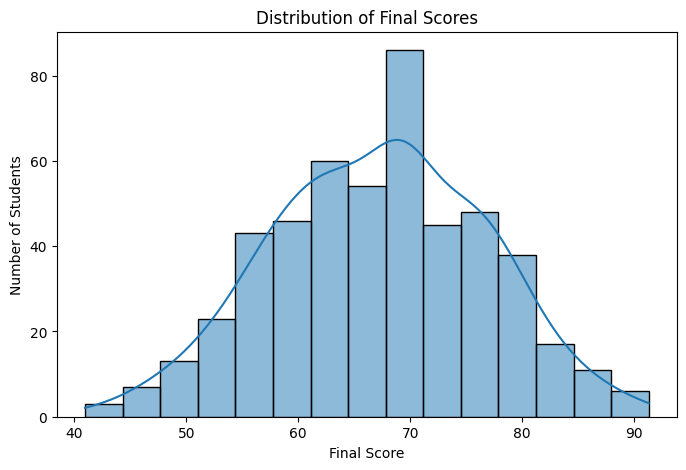

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df["Final_Score"], bins=15, kde=True)

plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()

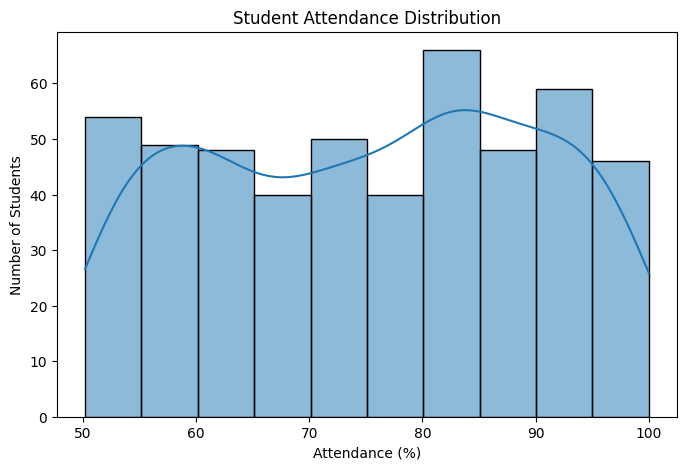

In [76]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Attendance"], bins=10, kde=True)

plt.title("Student Attendance Distribution")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")

plt.show()

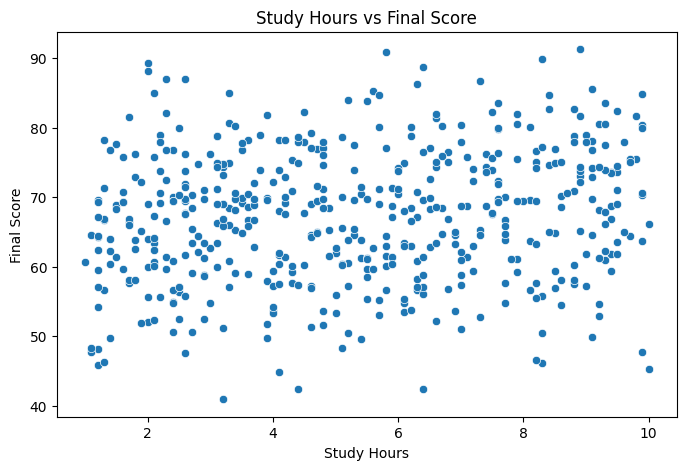

In [77]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Score"
)

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

plt.show()

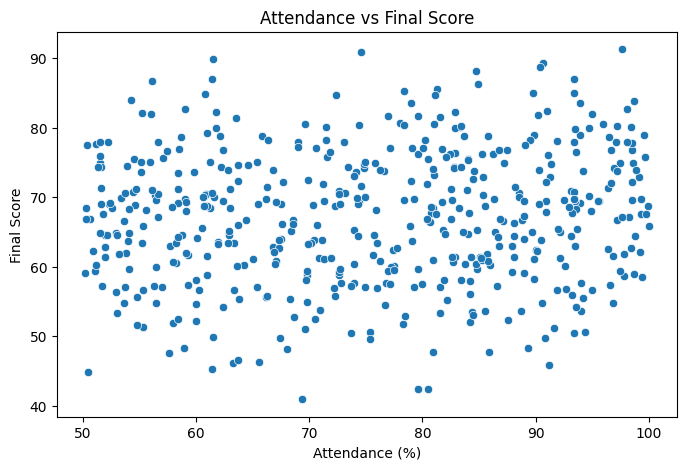

In [78]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Final_Score"
)

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")

plt.show()

In [79]:
subject_means = df[
    ["Math_Score", "Science_Score", "English_Score"]
].mean()

subject_means

,0
Math_Score,65.878
Science_Score,68.232
English_Score,67.734


Libraries imported successfully!

Dataset created successfully!

--- DATASET SHAPE ---
(500, 10)

--- FIRST 5 ROWS ---


,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
0,1,Male,21,5.4,60.9,66,91,64,61,70.41
1,2,Female,21,3.3,97.5,45,100,91,46,74.93
2,3,Male,17,5.1,89.3,44,50,81,51,48.36
3,4,Male,19,9.8,54.5,91,85,69,40,75.51
4,5,Male,18,5.4,70.9,59,73,53,39,61.21



--- COLUMN INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      500 non-null    int64  
 1   Gender          500 non-null    object 
 2   Age             500 non-null    int64  
 3   Study_Hours     500 non-null    float64
 4   Attendance      500 non-null    float64
 5   Math_Score      500 non-null    int64  
 6   Science_Score   500 non-null    int64  
 7   English_Score   500 non-null    int64  
 8   Previous_Score  500 non-null    int64  
 9   Final_Score     500 non-null    float64
dtypes: float64(3), int64(6), object(1)
memory usage: 39.2+ KB

--- STATISTICAL SUMMARY ---


,Student_ID,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,19.462000,5.294800,75.470200,65.878000,68.232000,67.734000,68.86400,67.186920
std,144.481833,1.715354,2.584836,14.637573,19.135502,18.584319,18.910591,19.17741,9.540479
min,1.000000,17.000000,1.000000,50.200000,35.000000,35.000000,35.000000,35.00000,40.960000
25%,125.750000,18.000000,3.075000,61.900000,50.000000,53.000000,51.000000,53.00000,60.440000
50%,250.500000,20.000000,5.200000,76.300000,65.000000,69.000000,68.000000,69.00000,67.810000
75%,375.250000,21.000000,7.500000,88.100000,83.000000,83.000000,85.000000,85.25000,74.355000
max,500.000000,22.000000,10.000000,100.000000,100.000000,100.000000,100.000000,100.00000,91.300000



--- MISSING VALUES ---
Student_ID        0
Gender            0
Age               0
Study_Hours       0
Attendance        0
Math_Score        0
Science_Score     0
English_Score     0
Previous_Score    0
Final_Score       0
dtype: int64

--- DUPLICATES ---
0

--- INVALID VALUES ---
Attendance below 0: 0
Attendance above 100: 0
Final scores below 0: 0
Final scores above 100: 0

--- BASIC PERFORMANCE ---
Average Final Score: 67.19
Average Attendance: 75.47 %
Average Study Hours: 5.29
Highest Final Score: 91.3
Lowest Final Score: 40.96

--- SUBJECT-WISE AVERAGE ---
Math_Score       65.88
Science_Score    68.23
English_Score    67.73
dtype: float64

Highest average subject: Science_Score
Lowest average subject: Math_Score


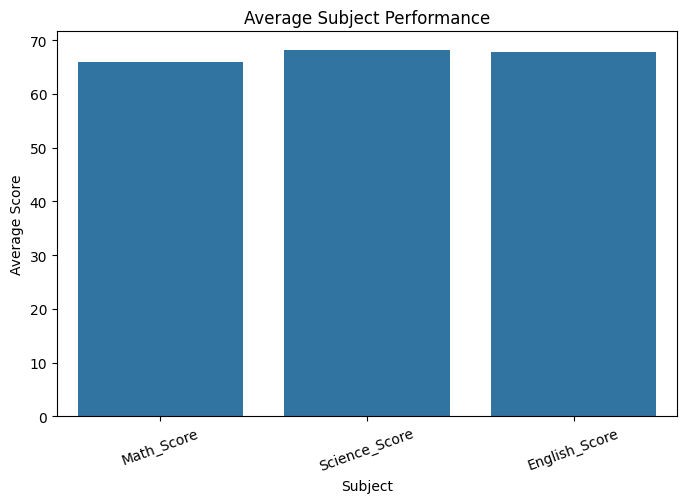

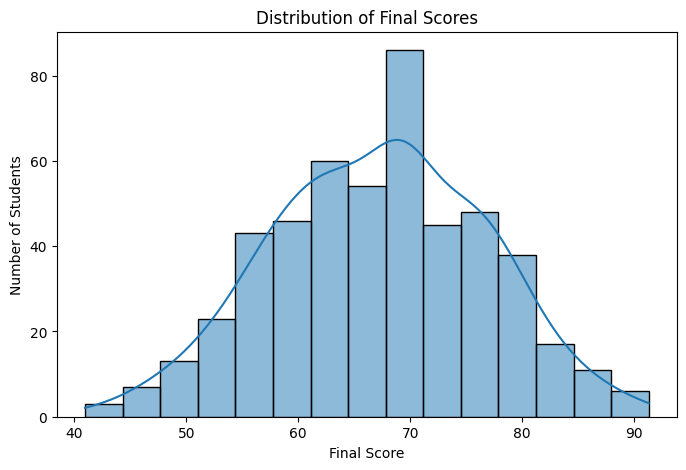

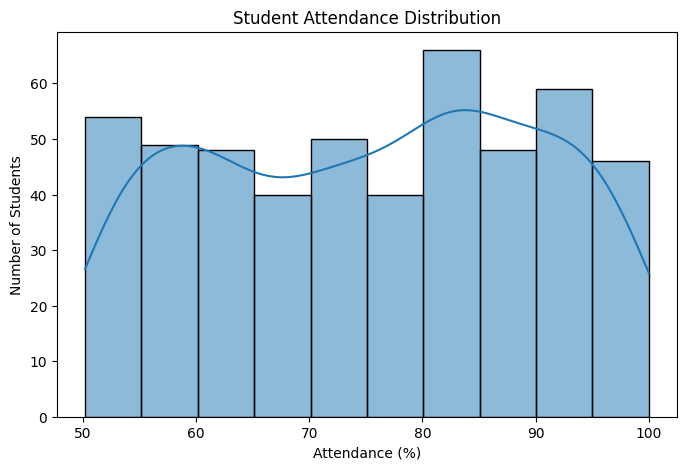

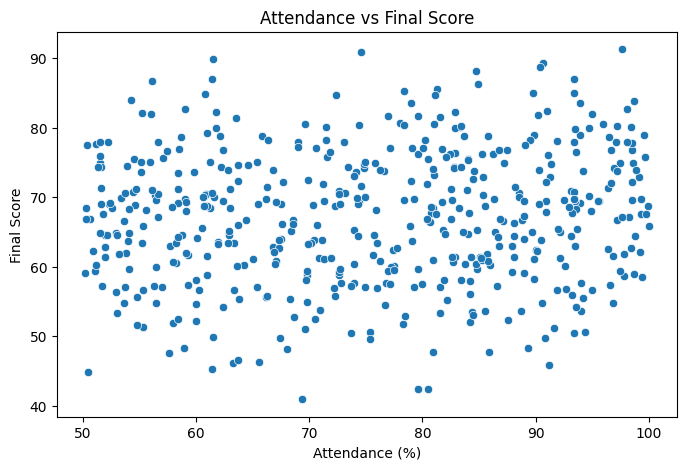

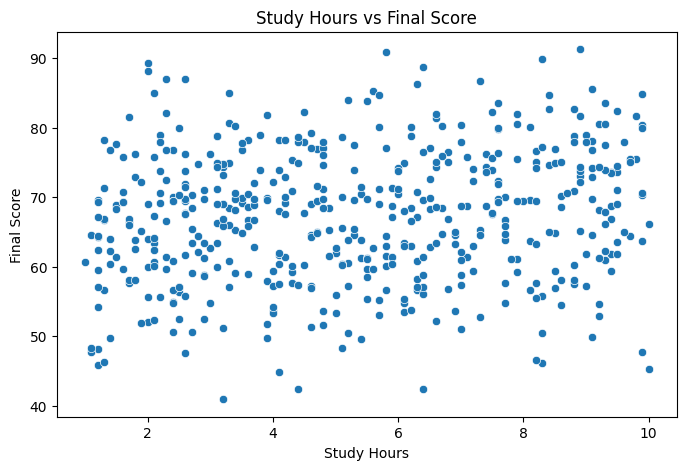


--- CORRELATION WITH FINAL SCORE ---
Attendance correlation: 0.099
Study Hours correlation: 0.154


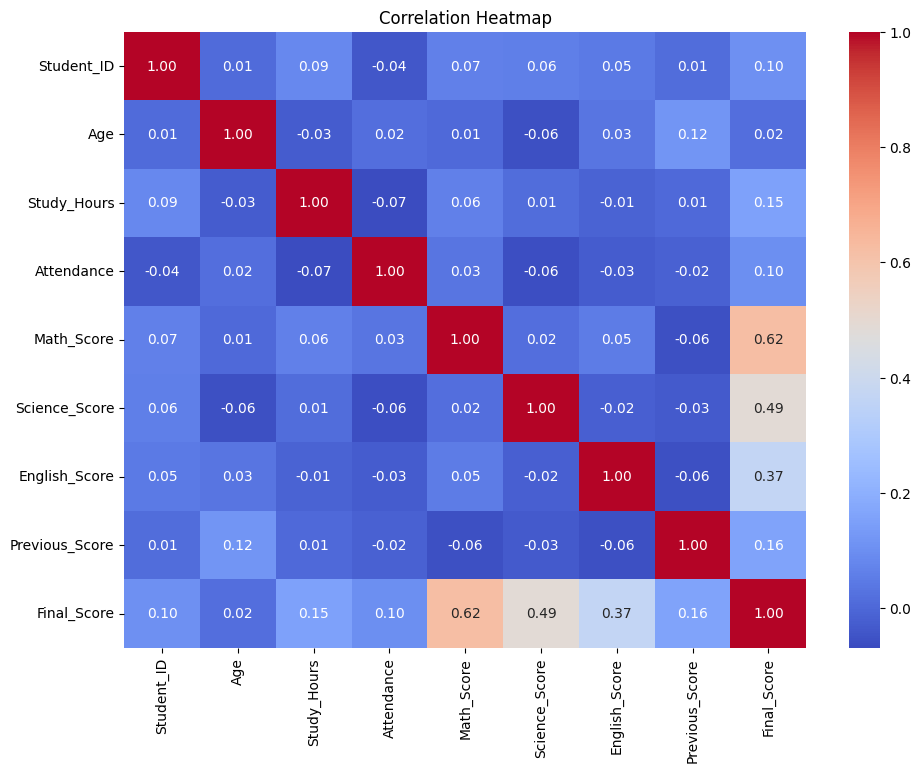


--- PERFORMANCE CATEGORIES ---
Performance_Category
Good         338
Average      117
Excellent     45
Name: count, dtype: int64


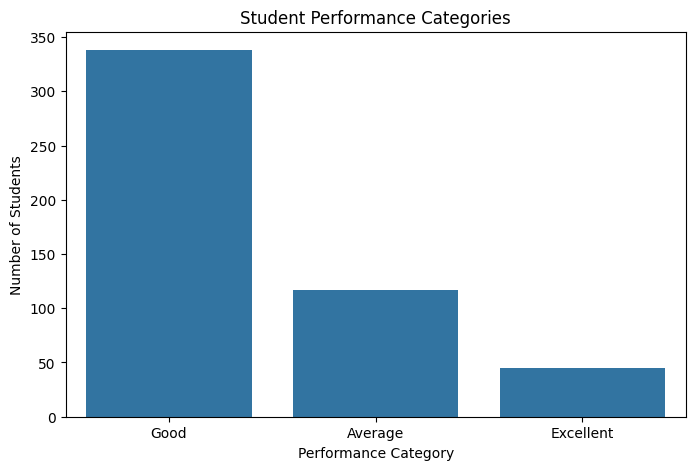


--- FINAL DATASET ---


,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score,Performance_Category,Average_Subject_Score,Attendance_Category,Study_Level
0,1,Male,21,5.4,60.9,66,91,64,61,70.41,Good,73.67,Moderate,High
1,2,Female,21,3.3,97.5,45,100,91,46,74.93,Good,78.67,Excellent,Moderate
2,3,Male,17,5.1,89.3,44,50,81,51,48.36,Average,58.33,Good,High
3,4,Male,19,9.8,54.5,91,85,69,40,75.51,Good,81.67,Low,Very High
4,5,Male,18,5.4,70.9,59,73,53,39,61.21,Good,61.67,Moderate,High



Final dataset shape: (500, 14)

Cleaned dataset saved successfully!
File: cleaned_student_performance.csv

DAY 1 COMPLETED

✓ Dataset creation
✓ Data understanding
✓ Missing-value check
✓ Duplicate check
✓ Data validation
✓ Basic statistics
✓ Subject-wise analysis
✓ Attendance analysis
✓ Study-hours analysis
✓ Performance visualization
✓ Correlation analysis
✓ Performance categories
✓ Feature engineering
✓ Cleaned dataset saved



In [80]:
# ============================================================
# STUDENT PERFORMANCE & LEARNING ANALYTICS - DAY 1
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")


# ============================================================
# 2. CREATE SYNTHETIC DATASET
# ============================================================

np.random.seed(42)

n = 500

df = pd.DataFrame({
    "Student_ID": range(1, n + 1),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Age": np.random.randint(17, 23, n),
    "Study_Hours": np.round(np.random.uniform(1, 10, n), 1),
    "Attendance": np.round(np.random.uniform(50, 100, n), 1),
    "Math_Score": np.random.randint(35, 101, n),
    "Science_Score": np.random.randint(35, 101, n),
    "English_Score": np.random.randint(35, 101, n),
    "Previous_Score": np.random.randint(35, 101, n)
})

# Generate final score using academic and learning factors
df["Final_Score"] = (
    0.30 * df["Math_Score"] +
    0.25 * df["Science_Score"] +
    0.20 * df["English_Score"] +
    0.10 * df["Previous_Score"] +
    0.10 * df["Attendance"] +
    0.05 * (df["Study_Hours"] * 10)
)

# Add small random variation
noise = np.random.normal(0, 4, n)

df["Final_Score"] = np.clip(
    df["Final_Score"] + noise,
    0,
    100
).round(2)

print("\nDataset created successfully!")


# ============================================================
# 3. BASIC DATA UNDERSTANDING
# ============================================================

print("\n--- DATASET SHAPE ---")
print(df.shape)

print("\n--- FIRST 5 ROWS ---")
display(df.head())

print("\n--- COLUMN INFORMATION ---")
df.info()

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())


# ============================================================
# 4. DATA CLEANING
# ============================================================

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- DUPLICATES ---")
print(df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Check invalid values
print("\n--- INVALID VALUES ---")
print("Attendance below 0:", (df["Attendance"] < 0).sum())
print("Attendance above 100:", (df["Attendance"] > 100).sum())
print("Final scores below 0:", (df["Final_Score"] < 0).sum())
print("Final scores above 100:", (df["Final_Score"] > 100).sum())


# ============================================================
# 5. BASIC PERFORMANCE ANALYSIS
# ============================================================

print("\n--- BASIC PERFORMANCE ---")

print("Average Final Score:",
      round(df["Final_Score"].mean(), 2))

print("Average Attendance:",
      round(df["Attendance"].mean(), 2), "%")

print("Average Study Hours:",
      round(df["Study_Hours"].mean(), 2))

print("Highest Final Score:",
      df["Final_Score"].max())

print("Lowest Final Score:",
      df["Final_Score"].min())


# ============================================================
# 6. SUBJECT-WISE PERFORMANCE
# ============================================================

subjects = [
    "Math_Score",
    "Science_Score",
    "English_Score"
]

subject_means = df[subjects].mean()

print("\n--- SUBJECT-WISE AVERAGE ---")
print(subject_means.round(2))

print("\nHighest average subject:",
      subject_means.idxmax())

print("Lowest average subject:",
      subject_means.idxmin())


# Subject visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    x=subject_means.index,
    y=subject_means.values
)

plt.title("Average Subject Performance")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.xticks(rotation=20)

plt.show()


# ============================================================
# 7. FINAL SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Final_Score"],
    bins=15,
    kde=True
)

plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()


# ============================================================
# 8. ATTENDANCE ANALYSIS
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Attendance"],
    bins=10,
    kde=True
)

plt.title("Student Attendance Distribution")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")

plt.show()


# Attendance vs Final Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Final_Score"
)

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")

plt.show()


# ============================================================
# 9. STUDY HOURS ANALYSIS
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Score"
)

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

plt.show()


# ============================================================
# 10. CORRELATION ANALYSIS
# ============================================================

attendance_corr = df["Attendance"].corr(
    df["Final_Score"]
)

study_corr = df["Study_Hours"].corr(
    df["Final_Score"]
)

print("\n--- CORRELATION WITH FINAL SCORE ---")

print("Attendance correlation:",
      round(attendance_corr, 3))

print("Study Hours correlation:",
      round(study_corr, 3))

# Correlation matrix
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


# ============================================================
# 11. PERFORMANCE CATEGORIES
# ============================================================

def performance_category(score):

    if score >= 80:
        return "Excellent"

    elif score >= 60:
        return "Good"

    elif score >= 40:
        return "Average"

    else:
        return "Needs Improvement"


df["Performance_Category"] = (
    df["Final_Score"].apply(performance_category)
)

print("\n--- PERFORMANCE CATEGORIES ---")
print(df["Performance_Category"].value_counts())


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Performance_Category"
)

plt.title("Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()


# ============================================================
# 12. FEATURE ENGINEERING
# ============================================================

# Average subject score
df["Average_Subject_Score"] = df[
    subjects
].mean(axis=1).round(2)

# Attendance category
df["Attendance_Category"] = pd.cut(
    df["Attendance"],
    bins=[0, 60, 75, 90, 100],
    labels=[
        "Low",
        "Moderate",
        "Good",
        "Excellent"
    ]
)

# Study level
df["Study_Level"] = pd.cut(
    df["Study_Hours"],
    bins=[0, 2, 5, 8, 24],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

print("\n--- FINAL DATASET ---")
display(df.head())

print("\nFinal dataset shape:", df.shape)


# ============================================================
# 13. SAVE CLEANED DATASET
# ============================================================

df.to_csv(
    "cleaned_student_performance.csv",
    index=False
)

print("\nCleaned dataset saved successfully!")
print("File: cleaned_student_performance.csv")


# ============================================================
# 14. FINAL DAY 1 SUMMARY
# ============================================================

print("\n" + "="*55)
print("DAY 1 COMPLETED")
print("="*55)

print("""
✓ Dataset creation
✓ Data understanding
✓ Missing-value check
✓ Duplicate check
✓ Data validation
✓ Basic statistics
✓ Subject-wise analysis
✓ Attendance analysis
✓ Study-hours analysis
✓ Performance visualization
✓ Correlation analysis
✓ Performance categories
✓ Feature engineering
✓ Cleaned dataset saved
""")

In [81]:
# ============================================================
# STUDENT PERFORMANCE & LEARNING ANALYTICS - DAY 2
# ============================================================

# ============================================================
# 15. IMPORT MACHINE LEARNING LIBRARIES
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Machine learning libraries imported successfully!")

Machine learning libraries imported successfully!


In [82]:
# ============================================================
# 16. SELECT FEATURES AND TARGET
# ============================================================

features = [
    "Study_Hours",
    "Attendance",
    "Math_Score",
    "Science_Score",
    "English_Score",
    "Previous_Score"
]

X = df[features]

y = df["Final_Score"]

print("Features:")
print(features)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['Study_Hours', 'Attendance', 'Math_Score', 'Science_Score', 'English_Score', 'Previous_Score']

Feature shape: (500, 6)
Target shape: (500,)


In [83]:
# ============================================================
# 17. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 400
Testing samples: 100


In [84]:
# ============================================================
# 18. CREATE LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [85]:
# ============================================================
# 19. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
[73.79883046 52.83932751 70.69354012 62.03101331 59.01736097 78.73069475
 72.06847208 62.49089177 57.23162761 71.40556946]


In [86]:
# ============================================================
# 20. ACTUAL VS PREDICTED SCORES
# ============================================================

comparison = pd.DataFrame({
    "Actual_Score": y_test.values,
    "Predicted_Score": np.round(y_pred, 2)
})

display(comparison.head(10))

,Actual_Score,Predicted_Score
0,78.85,73.80
1,56.60,52.84
2,69.76,70.69
3,69.01,62.03
4,57.10,59.02
5,83.50,78.73
6,78.62,72.07
7,59.46,62.49
8,58.22,57.23
9,81.90,71.41


In [87]:
# ============================================================
# 21. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("======================================")
print("MODEL EVALUATION")
print("======================================")

print("Mean Absolute Error (MAE):", round(mae, 3))
print("Mean Squared Error (MSE):", round(mse, 3))
print("Root Mean Squared Error (RMSE):", round(rmse, 3))
print("R² Score:", round(r2, 3))

MODEL EVALUATION
Mean Absolute Error (MAE): 3.623
Mean Squared Error (MSE): 20.133
Root Mean Squared Error (RMSE): 4.487
R² Score: 0.76


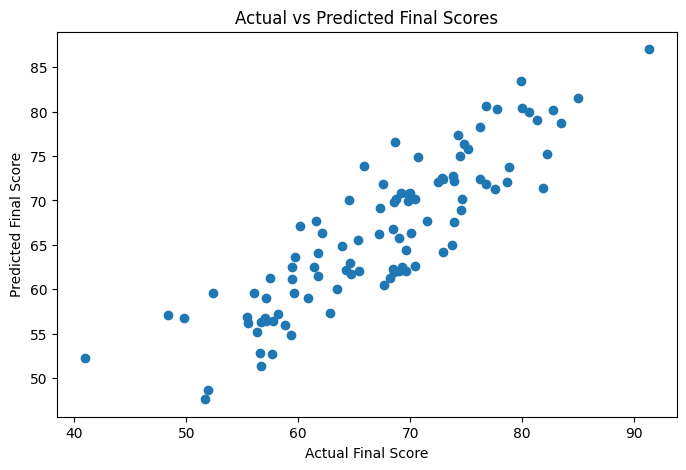

In [88]:
# ============================================================
# 22. ACTUAL VS PREDICTED VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")

plt.title("Actual vs Predicted Final Scores")

plt.show()

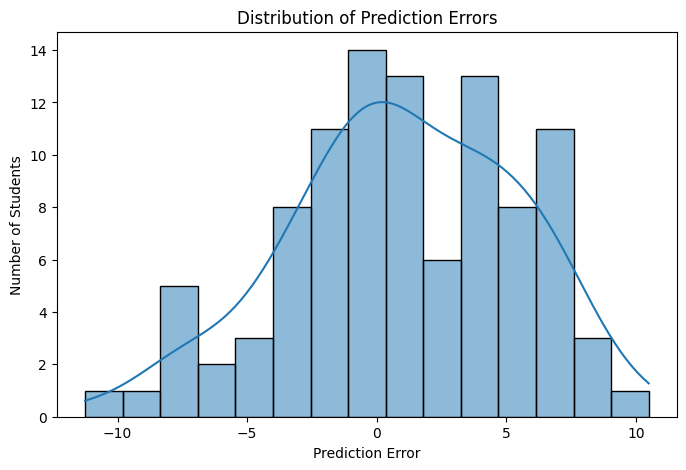

In [89]:
# ============================================================
# 23. PREDICTION ERROR ANALYSIS
# ============================================================

errors = y_test - y_pred

plt.figure(figsize=(8, 5))

sns.histplot(
    errors,
    bins=15,
    kde=True
)

plt.title("Distribution of Prediction Errors")

plt.xlabel("Prediction Error")

plt.ylabel("Number of Students")

plt.show()

In [90]:
# ============================================================
# 24. FEATURE COEFFICIENT ANALYSIS
# ============================================================

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficients)

,Feature,Coefficient
0,Study_Hours,0.433603
2,Math_Score,0.303717
3,Science_Score,0.261043
4,English_Score,0.182833
5,Previous_Score,0.114416
1,Attendance,0.084597


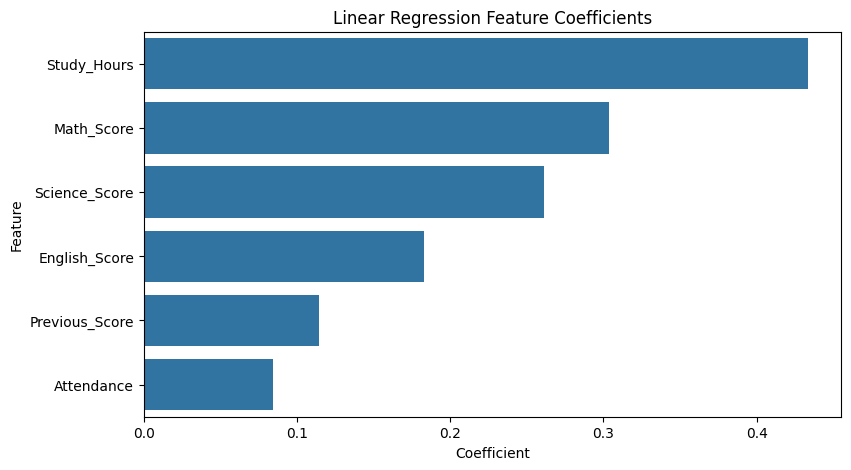

In [91]:
# ============================================================
# 25. FEATURE COEFFICIENT VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Coefficients")

plt.xlabel("Coefficient")

plt.ylabel("Feature")

plt.show()

In [92]:
# ============================================================
# 26. DAY 2 MODEL SUMMARY
# ============================================================

print("\n" + "="*60)
print("DAY 2 - PREDICTIVE MODELING SUMMARY")
print("="*60)

print("Model: Linear Regression")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nEvaluation Metrics:")
print("MAE :", round(mae, 3))
print("MSE :", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

print("\n✓ Features selected")
print("✓ Training/testing data separated")
print("✓ Linear Regression model trained")
print("✓ Predictions generated")
print("✓ Model evaluated")
print("✓ Prediction visualization created")
print("✓ Feature coefficients analyzed")


DAY 2 - PREDICTIVE MODELING SUMMARY
Model: Linear Regression
Training samples: 400
Testing samples: 100

Evaluation Metrics:
MAE : 3.623
MSE : 20.133
RMSE: 4.487
R²  : 0.76

✓ Features selected
✓ Training/testing data separated
✓ Linear Regression model trained
✓ Predictions generated
✓ Model evaluated
✓ Prediction visualization created
✓ Feature coefficients analyzed


In [93]:
# ============================================================
# DAY 2 - PREDICTIVE MODELING
# 15. IMPORT MACHINE LEARNING LIBRARIES
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Machine learning libraries imported successfully!")

Machine learning libraries imported successfully!


In [94]:
# ============================================================
# 16. SELECT FEATURES AND TARGET
# ============================================================

features = [
    "Study_Hours",
    "Attendance",
    "Math_Score",
    "Science_Score",
    "English_Score",
    "Previous_Score"
]

X = df[features]
y = df["Final_Score"]

print("Features:")
print(features)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['Study_Hours', 'Attendance', 'Math_Score', 'Science_Score', 'English_Score', 'Previous_Score']

Feature shape: (500, 6)
Target shape: (500,)


In [95]:
# ============================================================
# 17. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 400
Testing samples: 100


In [96]:
# ============================================================
# 18. TRAIN LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [97]:
# ============================================================
# 19. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(np.round(y_pred[:10], 2))

Predictions generated successfully!

First 10 predictions:
[73.8  52.84 70.69 62.03 59.02 78.73 72.07 62.49 57.23 71.41]


In [98]:
# ============================================================
# 20. ACTUAL VS PREDICTED SCORES
# ============================================================

comparison = pd.DataFrame({
    "Actual_Score": y_test.values,
    "Predicted_Score": np.round(y_pred, 2)
})

display(comparison.head(10))

,Actual_Score,Predicted_Score
0,78.85,73.80
1,56.60,52.84
2,69.76,70.69
3,69.01,62.03
4,57.10,59.02
5,83.50,78.73
6,78.62,72.07
7,59.46,62.49
8,58.22,57.23
9,81.90,71.41


In [99]:
# ============================================================
# 21. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("======================================")
print("MODEL EVALUATION")
print("======================================")

print("Mean Absolute Error (MAE):", round(mae, 3))
print("Mean Squared Error (MSE):", round(mse, 3))
print("Root Mean Squared Error (RMSE):", round(rmse, 3))
print("R² Score:", round(r2, 3))

MODEL EVALUATION
Mean Absolute Error (MAE): 3.623
Mean Squared Error (MSE): 20.133
Root Mean Squared Error (RMSE): 4.487
R² Score: 0.76


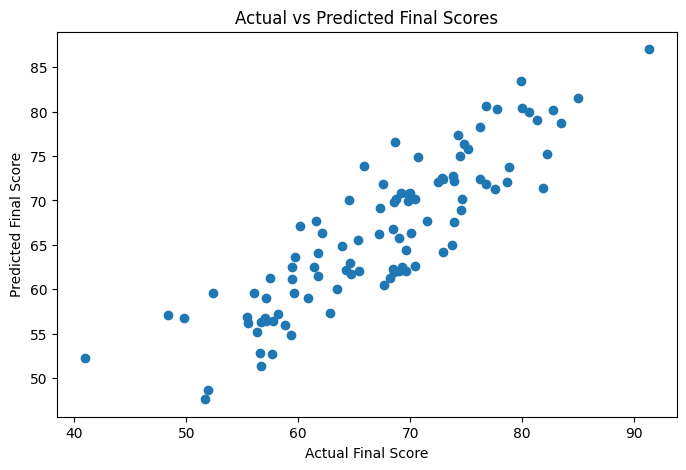

In [100]:
# ============================================================
# 22. ACTUAL VS PREDICTED VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Scores")

plt.show()

Average Prediction Error: 0.974
Minimum Error: -11.254
Maximum Error: 10.494


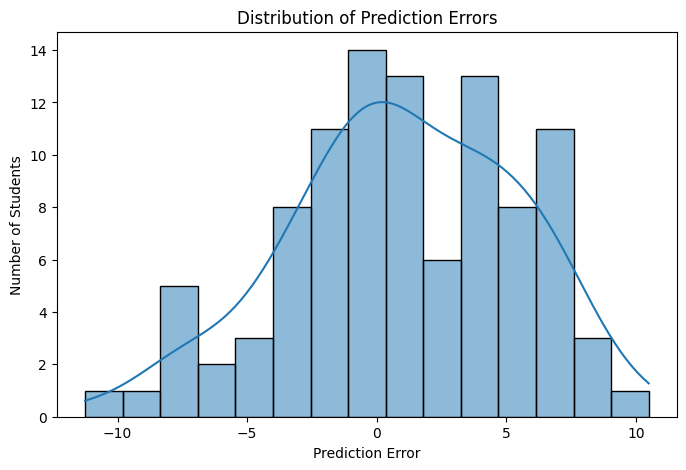

In [101]:
# ============================================================
# 23. PREDICTION ERROR ANALYSIS
# ============================================================

errors = y_test - y_pred

print("Average Prediction Error:",
      round(errors.mean(), 3))

print("Minimum Error:",
      round(errors.min(), 3))

print("Maximum Error:",
      round(errors.max(), 3))


plt.figure(figsize=(8, 5))

sns.histplot(
    errors,
    bins=15,
    kde=True
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Number of Students")

plt.show()

In [102]:
# ============================================================
# 24. FEATURE COEFFICIENT ANALYSIS
# ============================================================

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficients)

,Feature,Coefficient
0,Study_Hours,0.433603
2,Math_Score,0.303717
3,Science_Score,0.261043
4,English_Score,0.182833
5,Previous_Score,0.114416
1,Attendance,0.084597


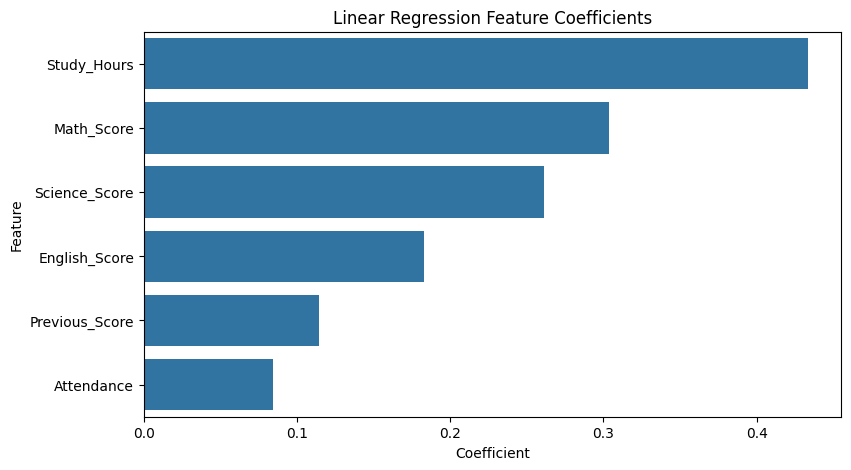

In [103]:
# ============================================================
# 25. FEATURE COEFFICIENT VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()


In [104]:
# ============================================================
# 26. FINAL DAY 2 SUMMARY
# ============================================================

print("\n" + "="*65)
print("STUDENT PERFORMANCE & LEARNING ANALYTICS - DAY 2")
print("="*65)

print("\nMODEL:")
print("Linear Regression")

print("\nDATA SPLIT:")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nMODEL EVALUATION:")
print("MAE :", round(mae, 3))
print("MSE :", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

print("\nPREDICTION ERROR:")
print("Average Error:", round(errors.mean(), 3))
print("Minimum Error:", round(errors.min(), 3))
print("Maximum Error:", round(errors.max(), 3))

print("\nKEY MODEL COEFFICIENTS:")

for feature, coefficient in zip(
    coefficients["Feature"],
    coefficients["Coefficient"]
):
    print(f"{feature}: {coefficient:.3f}")

print("\n" + "="*65)
print("DAY 2 COMPLETED")
print("="*65)

print("""
✓ Feature selection
✓ Train-test split
✓ Linear Regression model
✓ Model training
✓ Student score prediction
✓ Actual vs predicted analysis
✓ MAE, MSE, RMSE and R² evaluation
✓ Prediction error analysis
✓ Feature coefficient analysis
✓ Model visualizations
""")


STUDENT PERFORMANCE & LEARNING ANALYTICS - DAY 2

MODEL:
Linear Regression

DATA SPLIT:
Training samples: 400
Testing samples: 100

MODEL EVALUATION:
MAE : 3.623
MSE : 20.133
RMSE: 4.487
R²  : 0.76

PREDICTION ERROR:
Average Error: 0.974
Minimum Error: -11.254
Maximum Error: 10.494

KEY MODEL COEFFICIENTS:
Study_Hours: 0.434
Math_Score: 0.304
Science_Score: 0.261
English_Score: 0.183
Previous_Score: 0.114
Attendance: 0.085

DAY 2 COMPLETED

✓ Feature selection
✓ Train-test split
✓ Linear Regression model
✓ Model training
✓ Student score prediction
✓ Actual vs predicted analysis
✓ MAE, MSE, RMSE and R² evaluation
✓ Prediction error analysis
✓ Feature coefficient analysis
✓ Model visualizations



# Student Performance & Learning Analytics

## Project Overview

This project analyzes student academic and learning data to identify performance patterns, subject-wise performance, attendance trends, study habits, and factors associated with student outcomes.

The project follows a basic data science workflow:
Data Collection → Data Cleaning → EDA → Visualization → Correlation Analysis → Feature Engineering → Machine Learning → Evaluation → Insights


In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [106]:
np.random.seed(42)

n = 500

df = pd.DataFrame({
    "Student_ID": range(1, n + 1),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Age": np.random.randint(17, 23, n),
    "Study_Hours": np.round(np.random.uniform(1, 10, n), 1),
    "Attendance": np.round(np.random.uniform(50, 100, n), 1),
    "Math_Score": np.random.randint(35, 101, n),
    "Science_Score": np.random.randint(35, 101, n),
    "English_Score": np.random.randint(35, 101, n),
    "Previous_Score": np.random.randint(35, 101, n)
})

df["Final_Score"] = (
    0.30 * df["Math_Score"] +
    0.25 * df["Science_Score"] +
    0.20 * df["English_Score"] +
    0.10 * df["Previous_Score"] +
    0.10 * df["Attendance"] +
    0.05 * (df["Study_Hours"] * 10)
)

noise = np.random.normal(0, 4, n)

df["Final_Score"] = np.clip(
    df["Final_Score"] + noise, 0, 100
).round(2)

df.head()

,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
0,1,Male,21,5.4,60.9,66,91,64,61,70.41
1,2,Female,21,3.3,97.5,45,100,91,46,74.93
2,3,Male,17,5.1,89.3,44,50,81,51,48.36
3,4,Male,19,9.8,54.5,91,85,69,40,75.51
4,5,Male,18,5.4,70.9,59,73,53,39,61.21


In [107]:
subject_means = df[
    ["Math_Score", "Science_Score", "English_Score"]
].mean()

print(subject_means)

Math_Score       65.878
Science_Score    68.232
English_Score    67.734
dtype: float64


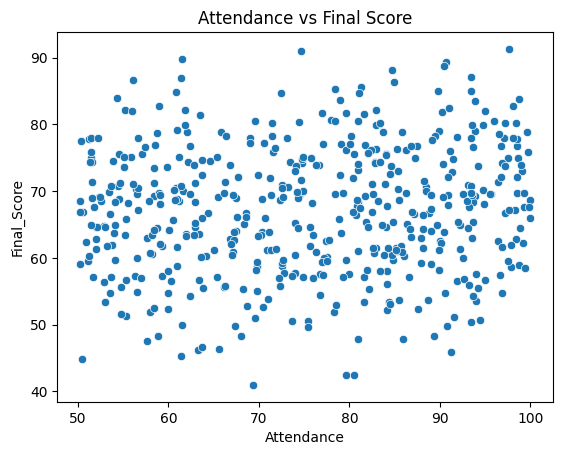

In [108]:
sns.scatterplot(
    data=df,
    x="Attendance",
    y="Final_Score"
)

plt.title("Attendance vs Final Score")
plt.show()

In [109]:
df["Average_Subject_Score"] = df[
    ["Math_Score", "Science_Score", "English_Score"]
].mean(axis=1)

In [110]:
df.to_csv("cleaned_student_performance.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [111]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [112]:
features = [
    "Study_Hours",
    "Attendance",
    "Math_Score",
    "Science_Score",
    "English_Score",
    "Previous_Score"
]

X = df[features]
y = df["Final_Score"]

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 400
Testing samples: 100


In [114]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [115]:
y_pred = model.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [116]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 3))
print("MSE :", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

MAE : 3.623
MSE : 20.133
RMSE: 4.487
R²  : 0.76


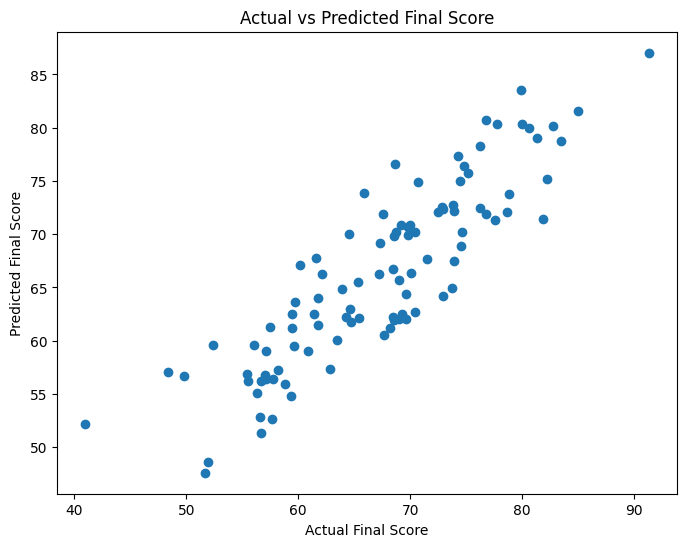

In [117]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score")

plt.show()

In [118]:
errors = y_test - y_pred

print("Average Prediction Error:", round(errors.mean(), 3))
print("Minimum Error:", round(errors.min(), 3))
print("Maximum Error:", round(errors.max(), 3))

Average Prediction Error: 0.974
Minimum Error: -11.254
Maximum Error: 10.494


In [119]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Study_Hours,0.433603
1,Attendance,0.084597
2,Math_Score,0.303717
3,Science_Score,0.261043
4,English_Score,0.182833
5,Previous_Score,0.114416


DAY 3 - FINAL ANALYSIS

Required feature-engineered columns created successfully.
   Average_Subject_Score Performance_Category Attendance_Category Study_Level
0              73.666667                 Good            Moderate        High
1              78.666667                 Good           Excellent    Moderate
2              58.333333              Average                Good        High
3              81.666667                 Good                 Low   Very High
4              61.666667                 Good            Moderate        High

1. PERFORMANCE CATEGORY ANALYSIS

Number of students in each category:
Performance_Category
Good         338
Average      117
Excellent     45
Name: count, dtype: int64


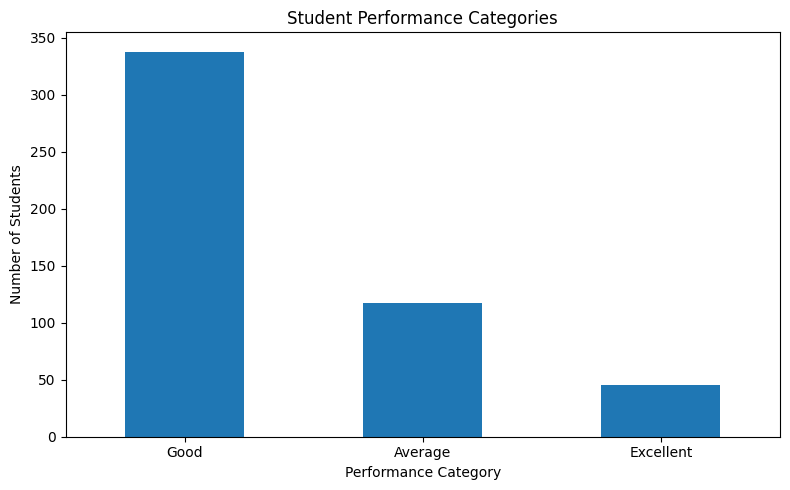


2. SUBJECT-WISE PERFORMANCE ANALYSIS

Average Subject Scores:
Math: 65.88
Science: 68.23
English: 67.73

Highest Average Subject: Science
Lowest Average Subject: Math


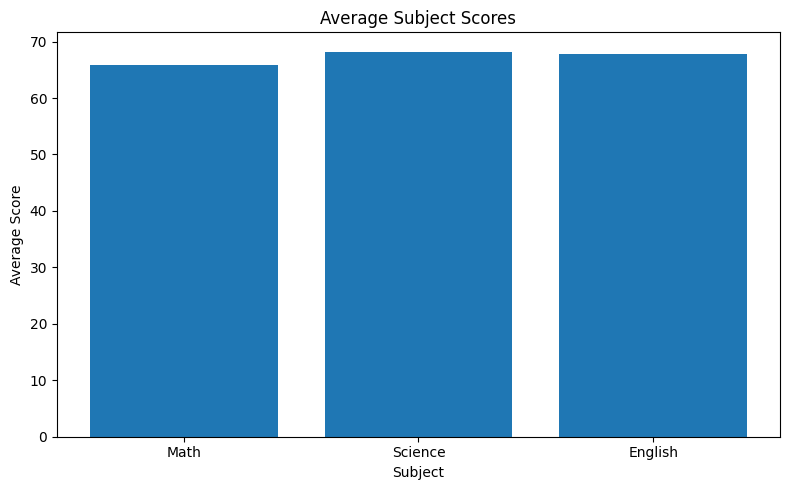


3. ATTENDANCE ANALYSIS

Average Final Score by Attendance Category:
Attendance_Category
Low          66.293824
Moderate     66.471942
Good         66.986299
Excellent    69.295238
Name: Final_Score, dtype: float64


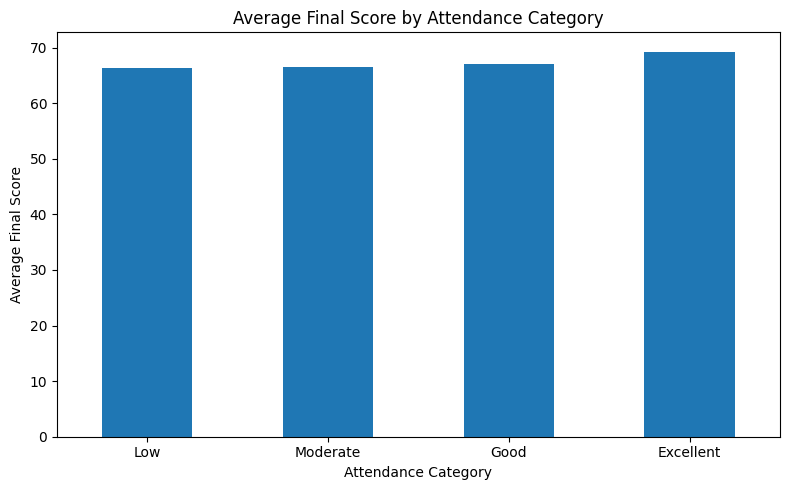


4. STUDY LEVEL ANALYSIS

Average Final Score by Study Level:
Study_Level
Low          64.331071
Moderate     66.648075
High         67.481090
Very High    69.313663
Name: Final_Score, dtype: float64


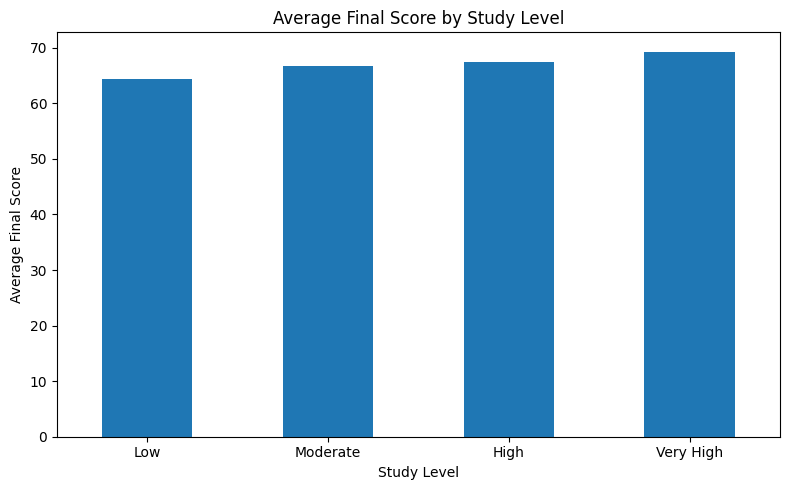


5. CORRELATION ANALYSIS

Correlation with Final Score:
Math_Score        0.624053
Science_Score     0.488881
English_Score     0.368411
Previous_Score    0.158461
Study_Hours       0.154089
Attendance        0.099442
Name: Final_Score, dtype: float64


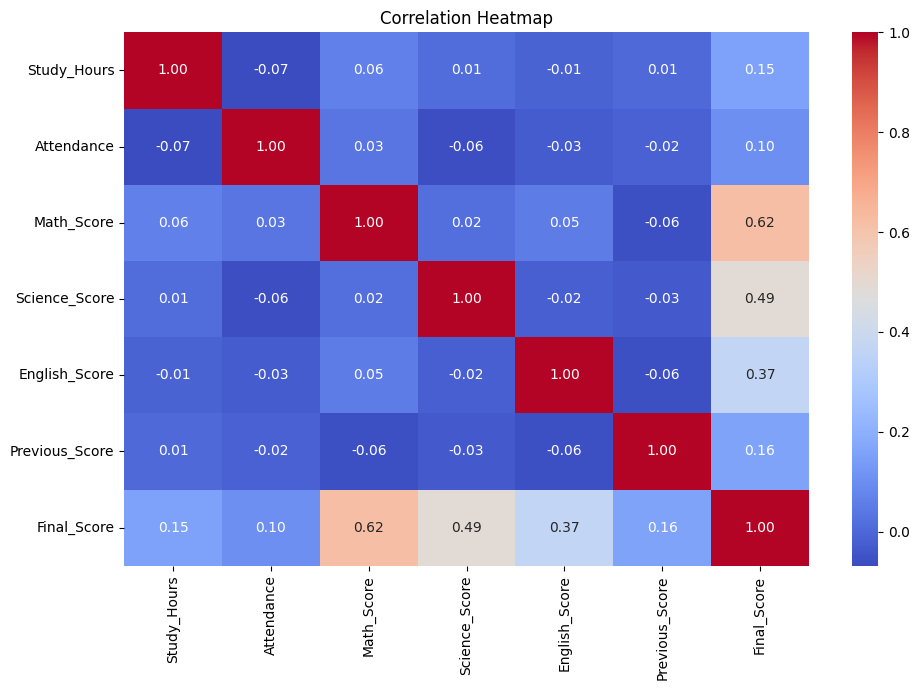


6. MACHINE LEARNING MODEL SUMMARY

Model: Linear Regression
MAE  : 3.623
MSE  : 20.133
RMSE : 4.487
R²   : 0.760

Prediction Error Analysis:
Average Prediction Error: 0.974
Minimum Error: -11.254
Maximum Error: 10.494


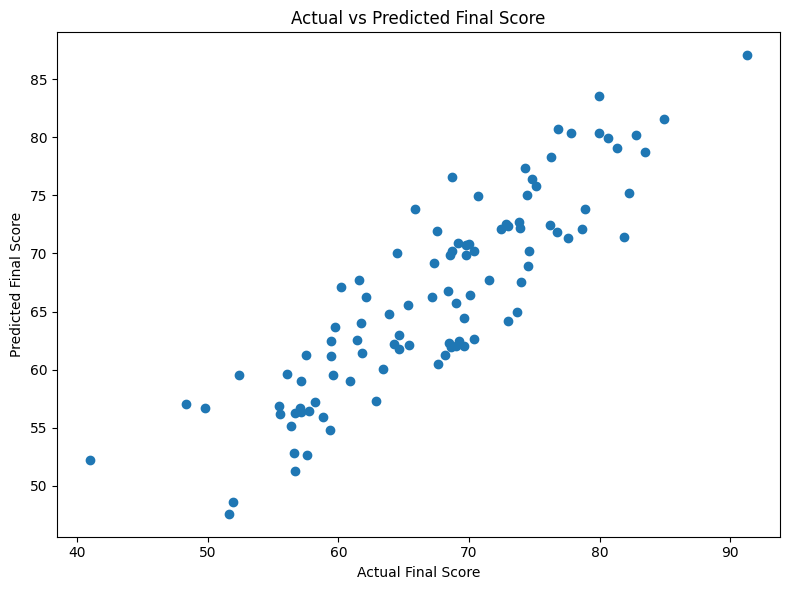


Model Coefficients:
          Feature  Coefficient
0     Study_Hours     0.433603
1      Attendance     0.084597
2      Math_Score     0.303717
3   Science_Score     0.261043
4   English_Score     0.182833
5  Previous_Score     0.114416


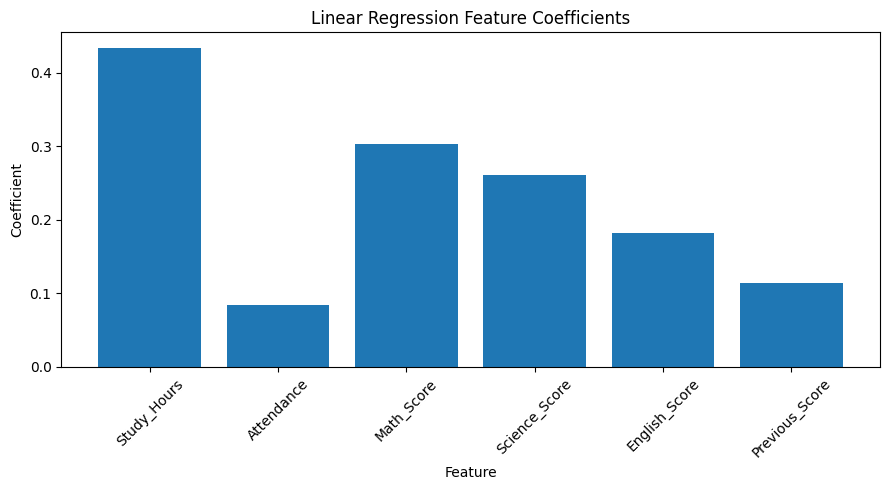


7. FINAL PROJECT INSIGHTS

1. Dataset contains 500 student records.

2. Highest average subject:
   Science

3. Lowest average subject:
   Math

4. Student performance was categorized into:
   Excellent, Good, Average, and Needs Improvement.

5. Attendance was grouped into:
   Low, Moderate, Good, and Excellent.

6. Study hours were grouped into:
   Low, Moderate, High, and Very High.

7. Correlation analysis was performed to examine
   relationships with Final Score.

8. Linear Regression was used to predict Final Score.

9. Model performance was evaluated using:
   MAE, MSE, RMSE, and R².

10. The dataset is synthetic and therefore the
    observed relationships should not be treated as
    real-world causal conclusions.

FINAL DATASET CHECK

Dataset Shape: (500, 14)

Final Columns:
['Student_ID', 'Gender', 'Age', 'Study_Hours', 'Attendance', 'Math_Score', 'Science_Score', 'English_Score', 'Previous_Score', 'Final_Score', 'Average_Subject_Score', 'Performance_Category', 'Attendance_

In [122]:
# ============================================================
# STUDENT PERFORMANCE & LEARNING ANALYTICS - DAY 3
# FINAL ANALYSIS, INSIGHTS & SUMMARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("DAY 3 - FINAL ANALYSIS")
print("=" * 60)


# ============================================================
# 1. CREATE / RECREATE REQUIRED FEATURE-ENGINEERED COLUMNS
# ============================================================

# Average Subject Score
df["Average_Subject_Score"] = df[
    ["Math_Score", "Science_Score", "English_Score"]
].mean(axis=1)


# Performance Category
def performance_category(score):
    if score >= 80:
        return "Excellent"
    elif score >= 60:
        return "Good"
    elif score >= 40:
        return "Average"
    else:
        return "Needs Improvement"

df["Performance_Category"] = df["Final_Score"].apply(
    performance_category
)


# Attendance Category
df["Attendance_Category"] = pd.cut(
    df["Attendance"],
    bins=[0, 60, 75, 90, 100],
    labels=["Low", "Moderate", "Good", "Excellent"],
    include_lowest=True
)


# Study Level
df["Study_Level"] = pd.cut(
    df["Study_Hours"],
    bins=[0, 2, 5, 8, 24],
    labels=["Low", "Moderate", "High", "Very High"],
    include_lowest=True
)


print("\nRequired feature-engineered columns created successfully.")

print(
    df[
        [
            "Average_Subject_Score",
            "Performance_Category",
            "Attendance_Category",
            "Study_Level"
        ]
    ].head()
)


# ============================================================
# 2. PERFORMANCE CATEGORY ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("1. PERFORMANCE CATEGORY ANALYSIS")
print("=" * 60)

performance_counts = df["Performance_Category"].value_counts()

print("\nNumber of students in each category:")
print(performance_counts)


plt.figure(figsize=(8, 5))

performance_counts.plot(kind="bar")

plt.title("Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# 3. SUBJECT-WISE PERFORMANCE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("2. SUBJECT-WISE PERFORMANCE ANALYSIS")
print("=" * 60)

subject_scores = {
    "Math": df["Math_Score"].mean(),
    "Science": df["Science_Score"].mean(),
    "English": df["English_Score"].mean()
}

print("\nAverage Subject Scores:")

for subject, score in subject_scores.items():
    print(f"{subject}: {score:.2f}")


strongest_subject = max(
    subject_scores,
    key=subject_scores.get
)

weakest_subject = min(
    subject_scores,
    key=subject_scores.get
)

print("\nHighest Average Subject:", strongest_subject)
print("Lowest Average Subject:", weakest_subject)


plt.figure(figsize=(8, 5))

plt.bar(
    subject_scores.keys(),
    subject_scores.values()
)

plt.title("Average Subject Scores")
plt.xlabel("Subject")
plt.ylabel("Average Score")

plt.tight_layout()
plt.show()


# ============================================================
# 4. ATTENDANCE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("3. ATTENDANCE ANALYSIS")
print("=" * 60)

attendance_summary = df.groupby(
    "Attendance_Category",
    observed=False
)["Final_Score"].mean()

print("\nAverage Final Score by Attendance Category:")
print(attendance_summary)


plt.figure(figsize=(8, 5))

attendance_summary.plot(kind="bar")

plt.title("Average Final Score by Attendance Category")
plt.xlabel("Attendance Category")
plt.ylabel("Average Final Score")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# 5. STUDY LEVEL ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("4. STUDY LEVEL ANALYSIS")
print("=" * 60)

study_summary = df.groupby(
    "Study_Level",
    observed=False
)["Final_Score"].mean()

print("\nAverage Final Score by Study Level:")
print(study_summary)


plt.figure(figsize=(8, 5))

study_summary.plot(kind="bar")

plt.title("Average Final Score by Study Level")
plt.xlabel("Study Level")
plt.ylabel("Average Final Score")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# 6. CORRELATION WITH FINAL SCORE
# ============================================================

print("\n" + "=" * 60)
print("5. CORRELATION ANALYSIS")
print("=" * 60)

correlation_columns = [
    "Study_Hours",
    "Attendance",
    "Math_Score",
    "Science_Score",
    "English_Score",
    "Previous_Score",
    "Final_Score"
]

correlations = df[
    correlation_columns
].corr()["Final_Score"].drop("Final_Score")

print("\nCorrelation with Final Score:")
print(correlations.sort_values(ascending=False))


# ============================================================
# 7. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[correlation_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# ============================================================
# 8. MODEL PERFORMANCE SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("6. MACHINE LEARNING MODEL SUMMARY")
print("=" * 60)

# Check whether Day 2 model variables exist
try:

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\nModel: Linear Regression")

    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.3f}")

except NameError:

    print("\nDay 2 model variables were not found.")
    print("Please run the Day 2 model training cells before Day 3.")


# ============================================================
# 9. PREDICTION ERROR ANALYSIS
# ============================================================

try:

    errors = y_test - y_pred

    print("\nPrediction Error Analysis:")

    print(
        f"Average Prediction Error: {errors.mean():.3f}"
    )

    print(
        f"Minimum Error: {errors.min():.3f}"
    )

    print(
        f"Maximum Error: {errors.max():.3f}"
    )

except NameError:

    print("\nPrediction variables not available.")


# ============================================================
# 10. ACTUAL VS PREDICTED VISUALIZATION
# ============================================================

try:

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_test,
        y_pred
    )

    plt.xlabel("Actual Final Score")
    plt.ylabel("Predicted Final Score")
    plt.title("Actual vs Predicted Final Score")

    plt.tight_layout()
    plt.show()

except NameError:

    print("\nActual and predicted values are not available.")


# ============================================================
# 11. MODEL COEFFICIENT ANALYSIS
# ============================================================

try:

    features = [
        "Study_Hours",
        "Attendance",
        "Math_Score",
        "Science_Score",
        "English_Score",
        "Previous_Score"
    ]

    coefficients = pd.DataFrame({
        "Feature": features,
        "Coefficient": model.coef_
    })

    print("\nModel Coefficients:")
    print(coefficients)


    plt.figure(figsize=(9, 5))

    plt.bar(
        coefficients["Feature"],
        coefficients["Coefficient"]
    )

    plt.title("Linear Regression Feature Coefficients")
    plt.xlabel("Feature")
    plt.ylabel("Coefficient")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

except NameError:

    print("\nModel coefficients are not available.")


# ============================================================
# 12. FINAL PROJECT INSIGHTS
# ============================================================

print("\n" + "=" * 60)
print("7. FINAL PROJECT INSIGHTS")
print("=" * 60)

print(f"""
1. Dataset contains {len(df)} student records.

2. Highest average subject:
   {strongest_subject}

3. Lowest average subject:
   {weakest_subject}

4. Student performance was categorized into:
   Excellent, Good, Average, and Needs Improvement.

5. Attendance was grouped into:
   Low, Moderate, Good, and Excellent.

6. Study hours were grouped into:
   Low, Moderate, High, and Very High.

7. Correlation analysis was performed to examine
   relationships with Final Score.

8. Linear Regression was used to predict Final Score.

9. Model performance was evaluated using:
   MAE, MSE, RMSE, and R².

10. The dataset is synthetic and therefore the
    observed relationships should not be treated as
    real-world causal conclusions.
""")


# ============================================================
# 13. FINAL DATASET CHECK
# ============================================================

print("=" * 60)
print("FINAL DATASET CHECK")
print("=" * 60)

print("\nDataset Shape:", df.shape)

print("\nFinal Columns:")
print(df.columns.tolist())


# ============================================================
# 14. SAVE FINAL DATASET
# ============================================================

df.to_csv(
    "final_student_performance_analysis.csv",
    index=False
)

print("\nFinal dataset saved as:")
print("final_student_performance_analysis.csv")


# ============================================================
# PROJECT COMPLETION
# ============================================================

print("\n" + "=" * 60)
print("DAY 3 COMPLETED SUCCESSFULLY")
print("STUDENT PERFORMANCE & LEARNING ANALYTICS COMPLETED")
print("=" * 60)